In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Download NLTK data
nltk.download('stopwords')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
from google.colab import files
uploaded = files.upload()

Saving combined_dataset.csv to combined_dataset.csv


In [5]:
# Load dataset
df = pd.read_csv('combined_dataset.csv', encoding='latin-1')

# Keep only required columns
df = df[['text', 'target']]
df = df.rename(columns={'text': 'messages', 'target': 'label'})

df.head()

,messages,label
0,Congratulations! You've been selected for a lu...,spam
1,URGENT: Your account has been compromised. Cli...,spam
2,You've won a free iPhone! Claim your prize by ...,spam
3,Act now and receive a 50% discount on all purc...,spam
4,Important notice: Your subscription will expir...,spam


In [6]:
# Check null values
df.isnull().sum()

,0
messages,0
label,0


In [7]:
# Text cleaning function
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^0-9a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# Apply cleaning
df['clean_text'] = df['messages'].apply(clean_text)

df.head()

,messages,label,clean_text
0,Congratulations! You've been selected for a lu...,spam,congratulations you ve been selected for a lux...
1,URGENT: Your account has been compromised. Cli...,spam,urgent your account has been compromised click...
2,You've won a free iPhone! Claim your prize by ...,spam,you ve won a free iphone claim your prize by c...
3,Act now and receive a 50% discount on all purc...,spam,act now and receive a 50 discount on all purch...
4,Important notice: Your subscription will expir...,spam,important notice your subscription will expire...


In [8]:
X = df['clean_text']
y = df['label']

In [9]:
def classify(model, X, y):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pipeline_model = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', model)
    ])

    pipeline_model.fit(x_train, y_train)

    print("Accuracy:", pipeline_model.score(x_test, y_test) * 100)

    y_pred = pipeline_model.predict(x_test)
    print(classification_report(y_test, y_pred))

    return pipeline_model

In [10]:
model_lr = LogisticRegression()
pipeline_lr = classify(model_lr, X, y)

Accuracy: 94.41809558555272
              precision    recall  f1-score   support

         ham       0.94      0.99      0.97      2139
        spam       0.97      0.77      0.86       602

    accuracy                           0.94      2741
   macro avg       0.95      0.88      0.91      2741
weighted avg       0.95      0.94      0.94      2741



In [11]:
model_nb = MultinomialNB()
pipeline_nb = classify(model_nb, X, y)

Accuracy: 87.88763225100328
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93      2139
        spam       1.00      0.45      0.62       602

    accuracy                           0.88      2741
   macro avg       0.93      0.72      0.77      2741
weighted avg       0.90      0.88      0.86      2741



In [12]:
model_svm = LinearSVC()
pipeline_svm = classify(model_svm, X, y)

Accuracy: 96.97190806275083
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98      2139
        spam       0.97      0.89      0.93       602

    accuracy                           0.97      2741
   macro avg       0.97      0.94      0.95      2741
weighted avg       0.97      0.97      0.97      2741



In [13]:
model_rf = RandomForestClassifier()
pipeline_rf = classify(model_rf, X, y)

Accuracy: 94.8194089748267
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97      2139
        spam       0.95      0.81      0.87       602

    accuracy                           0.95      2741
   macro avg       0.95      0.90      0.92      2741
weighted avg       0.95      0.95      0.95      2741



In [14]:
import pickle

# Save SVM model (best one)
with open('model.pkl', 'wb') as f:
    pickle.dump(pipeline_svm, f)

print("Model saved successfully!")

Model saved successfully!


In [15]:
# Load model
model = pickle.load(open('model.pkl', 'rb'))

# Test prediction
samples = [
    "Congratulations! You won a free ticket. Call now!",
    "Hey bro, let's meet tomorrow",
    "URGENT! claim your prize now",
    "Are you coming to class?"
]
for s in samples:
  clean_sample = clean_text(s)
  prediction = model.predict([clean_sample])

  print("Prediction:", prediction[0])

Prediction: spam
Prediction: ham
Prediction: spam
Prediction: ham


In [16]:
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import learning_curve

In [18]:
def classify(model, X, y, model_name="Model"):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pipeline_model = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', model)
    ])

    pipeline_model.fit(x_train, y_train)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", pipeline_model.score(x_test, y_test) * 100)

    y_pred = pipeline_model.predict(x_test)
    print(classification_report(y_test, y_pred))

    # 🔹 CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return pipeline_model, x_train, x_test, y_train, y_test


===== Logistic Regression =====
Accuracy: 94.41809558555272
              precision    recall  f1-score   support

         ham       0.94      0.99      0.97      2139
        spam       0.97      0.77      0.86       602

    accuracy                           0.94      2741
   macro avg       0.95      0.88      0.91      2741
weighted avg       0.95      0.94      0.94      2741



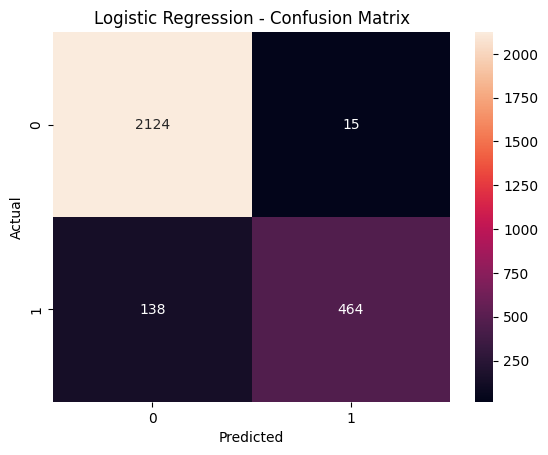


===== Naive Bayes =====
Accuracy: 87.88763225100328
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93      2139
        spam       1.00      0.45      0.62       602

    accuracy                           0.88      2741
   macro avg       0.93      0.72      0.77      2741
weighted avg       0.90      0.88      0.86      2741



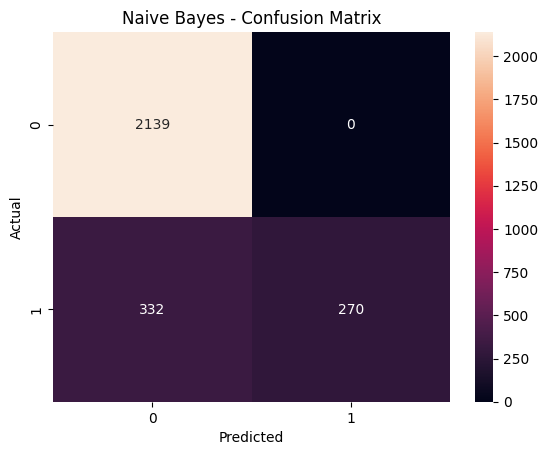


===== SVM =====
Accuracy: 96.97190806275083
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98      2139
        spam       0.97      0.89      0.93       602

    accuracy                           0.97      2741
   macro avg       0.97      0.94      0.95      2741
weighted avg       0.97      0.97      0.97      2741



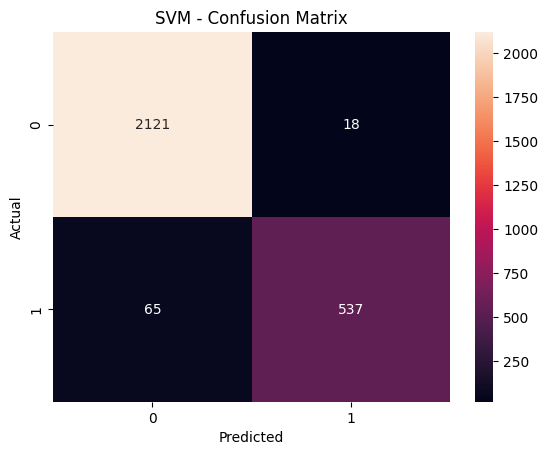


===== Random Forest =====
Accuracy: 95.2207223641007
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97      2139
        spam       0.95      0.83      0.88       602

    accuracy                           0.95      2741
   macro avg       0.95      0.91      0.93      2741
weighted avg       0.95      0.95      0.95      2741



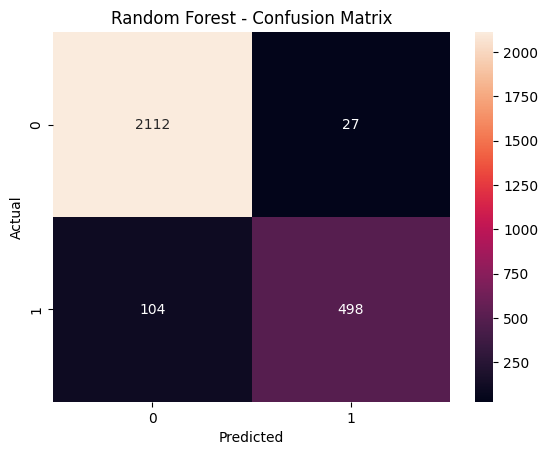

In [19]:
results = {}

model_lr = LogisticRegression()
pipeline_lr, x_train, x_test, y_train, y_test = classify(model_lr, X, y, "Logistic Regression")
results['Logistic Regression'] = pipeline_lr.score(x_test, y_test)

model_nb = MultinomialNB()
pipeline_nb, _, _, _, _ = classify(model_nb, X, y, "Naive Bayes")
results['Naive Bayes'] = pipeline_nb.score(x_test, y_test)

model_svm = LinearSVC()
pipeline_svm, _, _, _, _ = classify(model_svm, X, y, "SVM")
results['SVM'] = pipeline_svm.score(x_test, y_test)

model_rf = RandomForestClassifier()
pipeline_rf, _, _, _, _ = classify(model_rf, X, y, "Random Forest")
results['Random Forest'] = pipeline_rf.score(x_test, y_test)

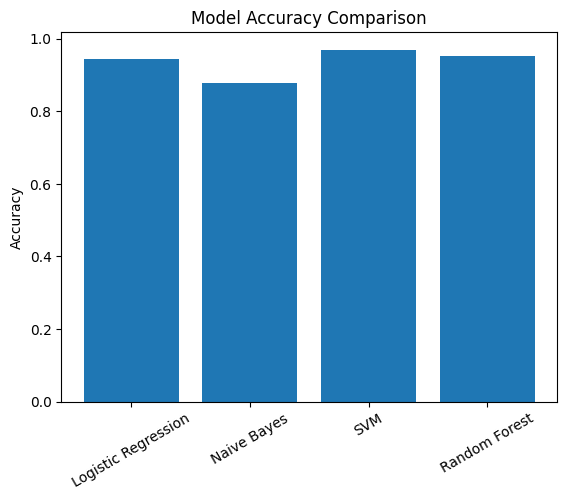

In [20]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

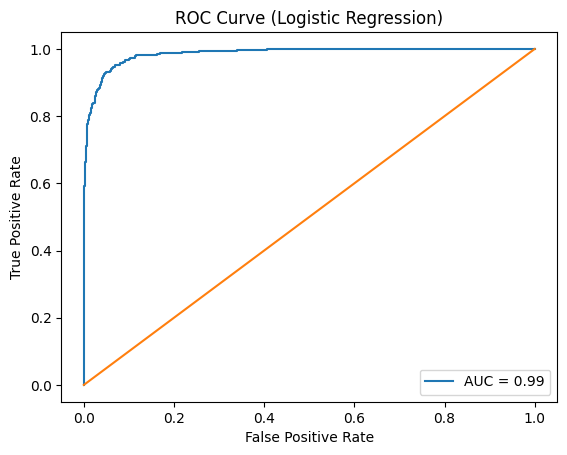

In [22]:
y_prob = pipeline_lr.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='spam')
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve (Logistic Regression)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

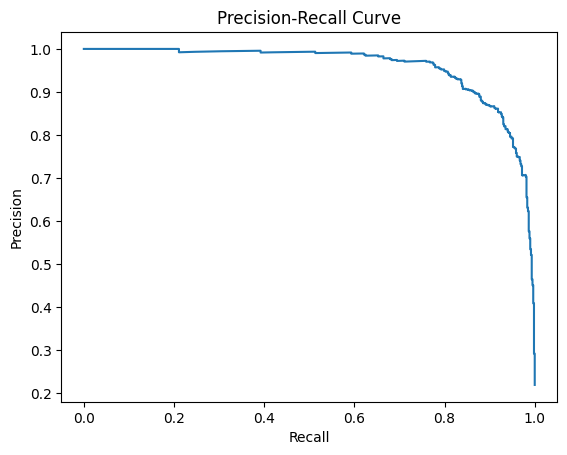

In [24]:
precision, recall, _ = precision_recall_curve(y_test, y_prob, pos_label='spam')

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

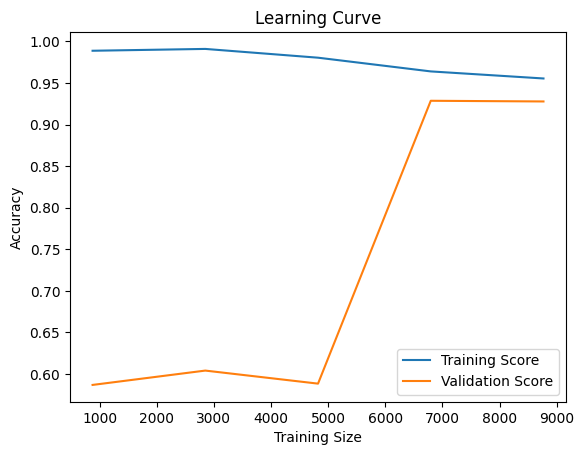

In [25]:
train_sizes, train_scores, test_scores = learning_curve(
    pipeline_lr, X, y, cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [26]:
vectorizer = pipeline_svm.named_steps['tfidf']
model = pipeline_svm.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_spam = np.argsort(coef)[-10:]
top_ham = np.argsort(coef)[:10]

print("\nTop Spam Words:")
print([feature_names[i] for i in top_spam])

print("\nTop Ham Words:")
print([feature_names[i] for i in top_ham])


Top Spam Words:
['remove', 'uk', '150p', '50', 'txt', 'info', 'claim', 'paliourg', 'mobile', 'http']

Top Ham Words:
['enron', 'cdnow', 'juno', 'thanks', 'texas', 'gt', 'attached', 'will', 'amazon', 'expedia']


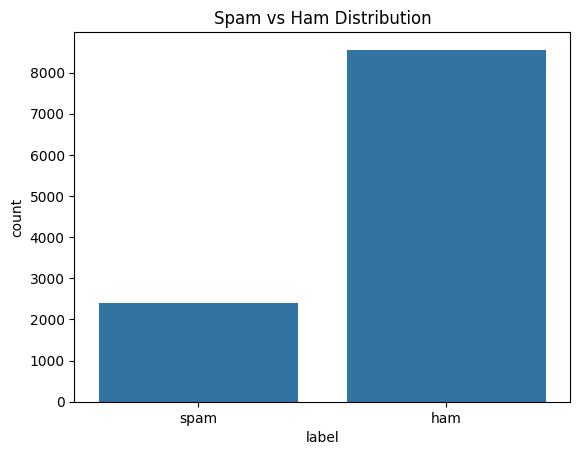

In [27]:
sns.countplot(x=y)
plt.title("Spam vs Ham Distribution")
plt.show()